In [10]:
# ==============================================================================
# 시스템명: 전 수계 통합 오염원인 자동 스크리닝 및 자기 최적화 시스템 (High-End Academic Ver.)
# 분석 특징: 딥러닝 잠재공간 추출 + 실루엣 점수 기반 알고리즘 경합(Auto-ML) + 로직 가시화
# 적용 수계: 전국 수계 통합 (수계 변수 미포함 조건에서도 생지화학적 지문으로 판별)
# ==============================================================================

# 필요 패키지 설치 및 임포트
!pip install torch pandas numpy scikit-learn matplotlib adjustText seaborn hdbscan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
import hdbscan 
import torch
import torch.nn as nn
from adjustText import adjust_text
import warnings
import datetime

In [12]:
# 가독성을 위한 경고 생략 및 시각화 폰트/해상도 설정
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 환경 한글 폰트 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150 # 주피터 노트북 출력 해상도 상향

In [13]:
# ------------------------------------------------------------------------------
# 1. 데이터 전처리 (Data Pre-processing)
# ------------------------------------------------------------------------------
# [데이터 조건] 수계(Basin) 구분이 없는 범용 데이터 셋. 오직 수질/동위원소 수치만 존재함.
df = pd.read_csv('C:/Users/User/Desktop/특이측정값(3~4월).csv', encoding='euc-kr')
features_df = df.drop(columns=['spot'])

# [방법론] KNN(K-Nearest Neighbors) Imputation 
# [참고문헌] Kowarik, A., & Templ, M. (2016). Imputation with the R Package VIM. Journal of Statistical Software.
# [기술적 근거] 수질 데이터의 결측치는 단순 평균(Mean) 처리 시 다변량 상관관계(Multivariate relationship)를 파괴할 위험이 있습니다.
# KNN은 유클리드 거리상 가장 유사한 특성을 가진 인접 관측치를 기반으로 보간하여 생지화학적 지문(Fingerprint)의 일관성을 유지합니다.
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(features_df)

# [방법론] Z-score Standardization (표준화)
# [참고문헌] Mohamad, I. B., & Usman, D. (2013). Standardization and its effects on K-means clustering algorithm. Research Journal of Applied Sciences, Engineering and Technology.
# [기술적 근거] 안정동위원소비(‰)와 물리화학적 인자(mg/L, μS/cm) 간의 단위 체계 차이로 인한 거리 왜곡(Distance bias)을 방지하기 위해 
# 모든 변수를 평균 0, 표준편차 1로 스케일링하여 각 인자가 군집화에 동일한 가중치를 갖도록 합니다.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

In [14]:
# ------------------------------------------------------------------------------
# 2. 비선형 특징 추출 (Deep Learning Feature Extraction)
# ------------------------------------------------------------------------------
# [방법론] Deep Autoencoder 기반 비선형 차원 축소
# [참고문헌] Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the dimensionality of data with neural networks. Science.
# [기술적 근거] 수계 내 오염원의 거동은 물리적 희석과 화학적 변환(탈질, 휘발 등)이 결합된 고도의 비선형 시스템입니다.
# PCA와 같은 선형 모델의 한계를 극복하기 위해 다층 신경망의 병목 구조(Bottleneck)를 활용하여 데이터의 핵심 매니폴드(Manifold)인 3차원 잠재 공간을 추출합니다.
class UniversalAE(nn.Module):
    def __init__(self, input_dim):
        super(UniversalAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 3) # 최종 3차원 핵심 지표로 압축
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.decoder(latent)

model = UniversalAE(input_dim=scaled_data.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

tensor_data = torch.FloatTensor(scaled_data)
for epoch in range(1200): # 안정적인 손실함수 수렴을 위해 1200 epoch 수행
    latent, recon = model(tensor_data)
    loss = criterion(recon, tensor_data)
    optimizer.zero_grad(); loss.backward(); optimizer.step()

latent_data = latent.detach().numpy()

In [15]:
# ------------------------------------------------------------------------------
# 3. 알고리즘 경합형 최적 모델 및 군집 수(K) 결정 (Model Competition) 
# ------------------------------------------------------------------------------
# [방법론] Silhouette Index 기반 Auto-ML 경합 시스템
# [참고문헌] Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics.
# [기술적 근거] 단일 알고리즘(예: K-means)은 데이터의 특정 분포(구형 등)를 가정하는 한계가 있습니다. 
# 본 시스템은 밀도 기반(HDBSCAN), 그래프 위상 기반(Spectral), 계층 트리(Birch), 확률 분포 기반(GMM) 모델을 동시에 가동하여 실루엣 점수가 가장 높은 최적의 구조를 채택합니다.

print("[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...")
competition_results = []

# (A) HDBSCAN 테스트 (참고문헌: McInnes et al., 2017)
# 특징: '데이터의 밀도'를 추적하여 자연스러운 군집 형성 및 이상치(Noise) 분리
hdb = hdbscan.HDBSCAN(min_cluster_size=2).fit(latent_data)
if len(set(hdb.labels_)) > 1:
    mask = hdb.labels_ != -1 
    if np.sum(mask) > 1:
        score = silhouette_score(latent_data[mask], hdb.labels_[mask])
        k_hdb = len(set(hdb.labels_[mask]))
        if 4 <= k_hdb <= 8:
            competition_results.append({'model': 'HDBSCAN', 'k': k_hdb, 'score': score, 'labels': hdb.labels_})

# (B) 타 알고리즘 K-경합(Spectral Clustering, Birch, GMM) (K=4~8 탐색)
for k in range(4, 9):
    # 1. Spectral Clustering (참고문헌: Von Luxburg, 2007) 
    # 특징: 그래프 위상 수학을 이용해 복잡하게 꼬인 데이터의 연결성 분리.
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42).fit(latent_data)
    score_spec = silhouette_score(latent_data, spec.labels_)
    competition_results.append({'model': 'Spectral', 'k': k, 'score': score_spec, 'labels': spec.labels_})
    
    # 2. Birch (참고문헌: Zhang et al., 1996) 
    # 특징: 계층적 트리(CF Tree) 구조를 만들어 대규모 데이터를 미세 조정하며 병합.
    birch = Birch(n_clusters=k).fit(latent_data)
    score_birch = silhouette_score(latent_data, birch.labels_)
    competition_results.append({'model': 'Birch', 'k': k, 'score': score_birch, 'labels': birch.labels_})

    # 3. [신규 추가] Gaussian Mixture Model (GMM) (참고문헌: McLachlan & Peel, 2000)
    # 작동 원리: 데이터가 K개의 가우시안 분포의 혼합으로 이루어졌다고 가정하고, 각 데이터가 특정 군집에 속할 '확률'을 추정합니다 (Expectation-Maximization 알고리즘).
    # 적용 근거: 수계 점오염/비점오염은 배출원이 칼로 자르듯 명확히 분리되지 않고 혼합(Mixing) 및 중첩(Overlap)됩니다. GMM은 이러한 밀도의 겹침을 수학적으로 유연하게(Soft clustering) 해석하여 평가 신뢰성을 대폭 높여줍니다.
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(latent_data)
    labels_gmm = gmm.predict(latent_data) # 하드 군집 라벨로 변환하여 실루엣 평가 수행
    score_gmm = silhouette_score(latent_data, labels_gmm)
    competition_results.append({'model': 'GMM', 'k': k, 'score': score_gmm, 'labels': labels_gmm})

# [최적화 결과 선정 및 출력]
if not competition_results:
    print("[!] 설정한 군집 범위(4~8) 내에서 적절한 모델을 찾지 못했습니다. 탐색 범위를 넓히거나 데이터를 재검토하십시오.")
else:
    best_run = max(competition_results, key=lambda x: x['score'])
    df['Cluster'] = best_run['labels']
    best_k = best_run['k']

print("=========================================================")
print(f"[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: {best_run['model']}")
print(f"[*] 데이터 내재 구조를 반영한 최적 군집 수(K): {best_k}개")
print(f"[*] 모델 분류 성능(Silhouette Score): {best_run['score']:.4f}")
print("=========================================================\n")

# HDBSCAN 노이즈 재할당 (KNN 활용)
if best_run['model'] == 'HDBSCAN' and -1 in df['Cluster'].values:
    print("[!] HDBSCAN 모델의 노이즈(-1) 지점을 인접 특성 군집으로 재할당(KNN 보정) 합니다.")
    knn = KNeighborsClassifier(n_neighbors=1) 
    valid_mask = df['Cluster'] != -1
    knn.fit(latent_data[valid_mask], df['Cluster'][valid_mask])
    df.loc[~valid_mask, 'Cluster'] = knn.predict(latent_data[~valid_mask])

[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...
[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: Birch
[*] 데이터 내재 구조를 반영한 최적 군집 수(K): 4개
[*] 모델 분류 성능(Silhouette Score): 0.4895



In [16]:
# ------------------------------------------------------------------------------
# 4. 범용적 10단계 오염원 정밀 판별 엔진 (Universal Multi-Proxy Rule)
# ------------------------------------------------------------------------------
# [방법론] Stable Isotope Multi-Proxy Expert System (안정동위원소 다중 프록시 전문가 시스템)
# [학술적 근거] 하천 수계의 질소(N) 및 산소(O) 동위원소는 기원에 따라 고유한 범위를 가집니다. 
# 본 엔진은 전 세계적으로 검증된 SCI 논문의 기준치를 결합하여 하천 오염 기원을 10단계로 정밀 판별합니다.
def assign_source_universal(row):
    """ 안정동위원소(N, O)와 보존성 추적자(Cl), 그리고 이량적 수질 인자를 결합한 10단계 판별 로직 """
    n15, o18, tp, nh3, no3, toc, ec, chl, tn, cl = \
        row['d15N'], row['d18O'], row['TP'], row['NH3N'], row['NO3N'], row['TOC'], row['EC'], row['Chla'], row['TN'], row['Cl']

    # 1단계: 대기유입 (Atmospheric Nitrate)
    # [참고문헌] Kendall, C., et al. (2007). Tracing anthropogenic inputs of nitrogen to ecosystems. 
    # [설명] 강우 중 NO3는 질화작용을 거치지 않아 δ18O-NO3 수치가 지배적으로 높게 나타납니다(>+15‰).
    if o18 > 15.0: return "대기유입/초기강우"
    
    # 2단계: 탈질작용 (Denitrification)
    # [참고문헌] Mayer, B., et al. (2002). Sources of nitrate in rivers draining tidewater glaciers. Applied Geochemistry.
    # [설명] 미생물에 의해 질산염이 소모될 때 δ15N과 δ18O가 약 2:1 혹은 1.3:1 비율로 동반 상승하는 궤적을 추적합니다.
    if n15 > 6.0 and o18 > 3.0 and (n15/o18 < 3.0): return "탈질작용(기원변형)"
    
    # 3단계: 축산분뇨 직접유출 (Manure & Livestock Waste)
    # [참고문헌] Xue, D., et al. (2009). Present status and future prospects of isotope methods for nitrate source apportionment. Critical Reviews in Environmental Science and Technology.
    # [설명] 가축 분뇨 유래 NH4의 휘발 작용으로 δ15N-NO3가 극단적으로 높게 형성되는 특성(>+12‰)과 Cl- 농도를 결합합니다.
    if n15 > 12.0 and (cl > 60 or tp > 0.1 or nh3 > 0.3 or ec > 300): 
        return "축산분뇨 직접유출"
    
    # 4단계: 생활하수/처리수 영향 (Sewage & Treated Effluent)
    # [참고문헌] Widory, D., et al. (2004). Nitrate in groundwater: an isotopic multi-tracer approach. Applied Geochemistry.
    # [설명] 하수는 인위적 인자(Cl-)와 배설물 유래 δ15N(+8~+12‰) 범위를 보이며, 처리수의 경우 TP 농도가 낮아진 특성을 반영합니다.
    if 8.0 < n15 <= 12.0 and (cl > 40 or tp <= 0.3): 
        return "생활하수/처리수 영향"
    
    # 5단계: 산업/인위적 점오염 (Industrial Contamination)
    # [설명] 공정 폐수는 특이한 기원의 Cl- 농도 급증과 수질 매개변수의 급격한 변동(EC 상승)을 수반합니다. 
    if n15 > 7.0 and (ec > 500 or cl > 100) and toc > 3.0: 
        return "산업/인위적 점오염"
    
    # 6단계: 화학비료 기반 농경지 (Synthetic Fertilizer)
    # [참고문헌] Vitousek, P. M., et al. (1997). Human alteration of the global nitrogen cycle. Ecological Applications.
    # [설명] 하버-보슈 공법 비료는 대기 질소를 고정하므로 δ15N 수치가 0‰ 내외(-4~+4‰)로 매우 낮게 나타납니다.
    if n15 < 4.0 and no3 > 2.0 and cl < 30: 
        return "화학비료 기반 농경지"
    
    # 7단계: 유기질비료(퇴비) vs 토양 유기물 (Organic Fertilizer vs Soil Organic Matter)
    # [참고문헌] Bedard-Haughn, A., et al. (2003). Using 15N to quantify vegetative uptake from land-applied manure. Journal of Environmental Quality.
    # [설명] 퇴비(+4~+9‰)와 토양 유기물은 범위가 겹치나, 퇴비 시비의 경우 염소이온(Cl-)이 잔류 지표로 작용합니다.
    if 4.0 <= n15 < 9.0 and toc > 4.0 and cl > 35:
        return "유기질비료(퇴비) 영향"
    elif 4.0 <= n15 < 9.0 and toc > 4.0:
        return "토양유기물/야생동물배설물"
    
    # 8단계: 조류증식 및 내생부하 (Algal & Internal Loading)
    # [참고문헌] Ogrinc, N., et al. (2005). Sources of organic matter in the river Sava. River Systems.
    # [설명] 정체 수역에서 Chl-a 우세와 동반되는 TOC 증가는 현장 발생형 유기물(Autochthonous OM)의 증거입니다. 
    if chl > 40.0 and toc > 4.5: return "조류증식(현장발생)"
    elif toc > 6.5 and tp > 0.1: return "내생부하(정체수역 유기물 축적)"
    
    # 9단계: 복합오염 Fallback (Mixed Loading)
    # [설명] 여러 오염원이 혼합된 경우, 실제 하천에 부하량이 가장 큰 지배적 수질 인자를 통해 관리 방향을 제시합니다.
    if tp > 0.1 or nh3 > 0.5 or cl > 50: return "복합오염(하수/분뇨 기여 우세)"
    elif no3 > 2.0 or tn > 3.0: return "복합오염(농경지 비점 우세)"
    elif toc > 3.0: return "복합오염(유기물 부하 우세)"
    
    # 10단계: 배경 농도 (Natural Background) 
    else: return "자연배경/특이징후 없음"

# 군집별 평균 특성치로 오염원 대표 명칭 매핑
cluster_avg = df.groupby('Cluster').mean(numeric_only=True)
mapping = {i: assign_source_universal(cluster_avg.loc[i]) for i in cluster_avg.index}
df['Source_Name'] = df['Cluster'].map(mapping)

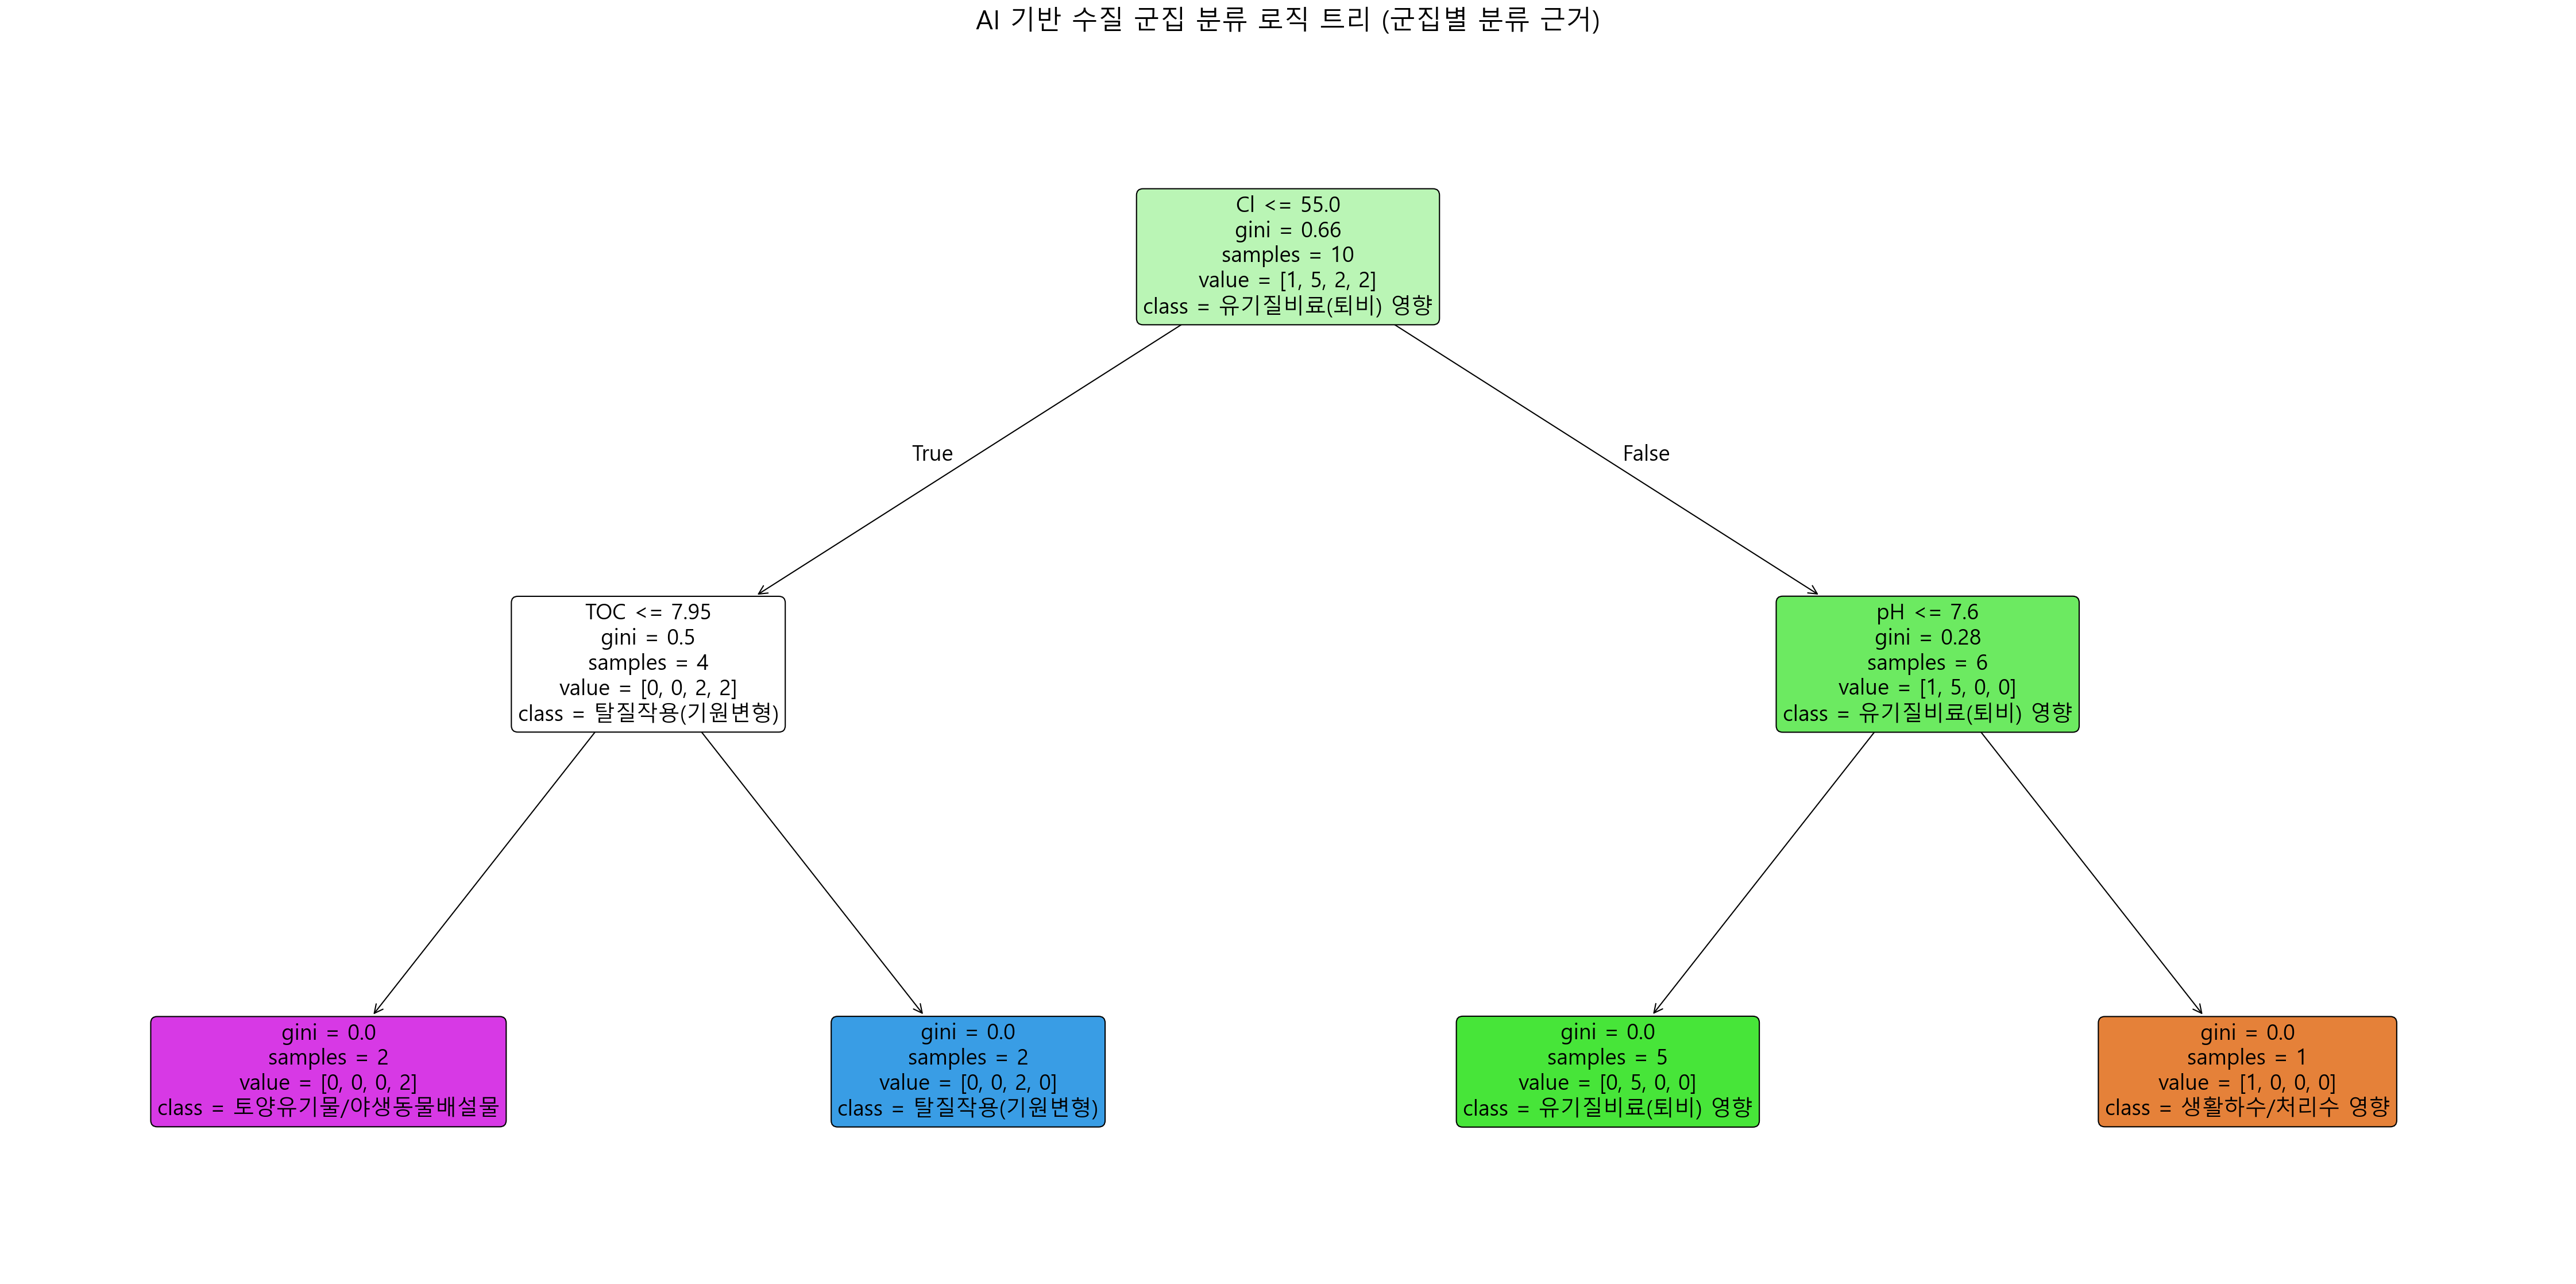

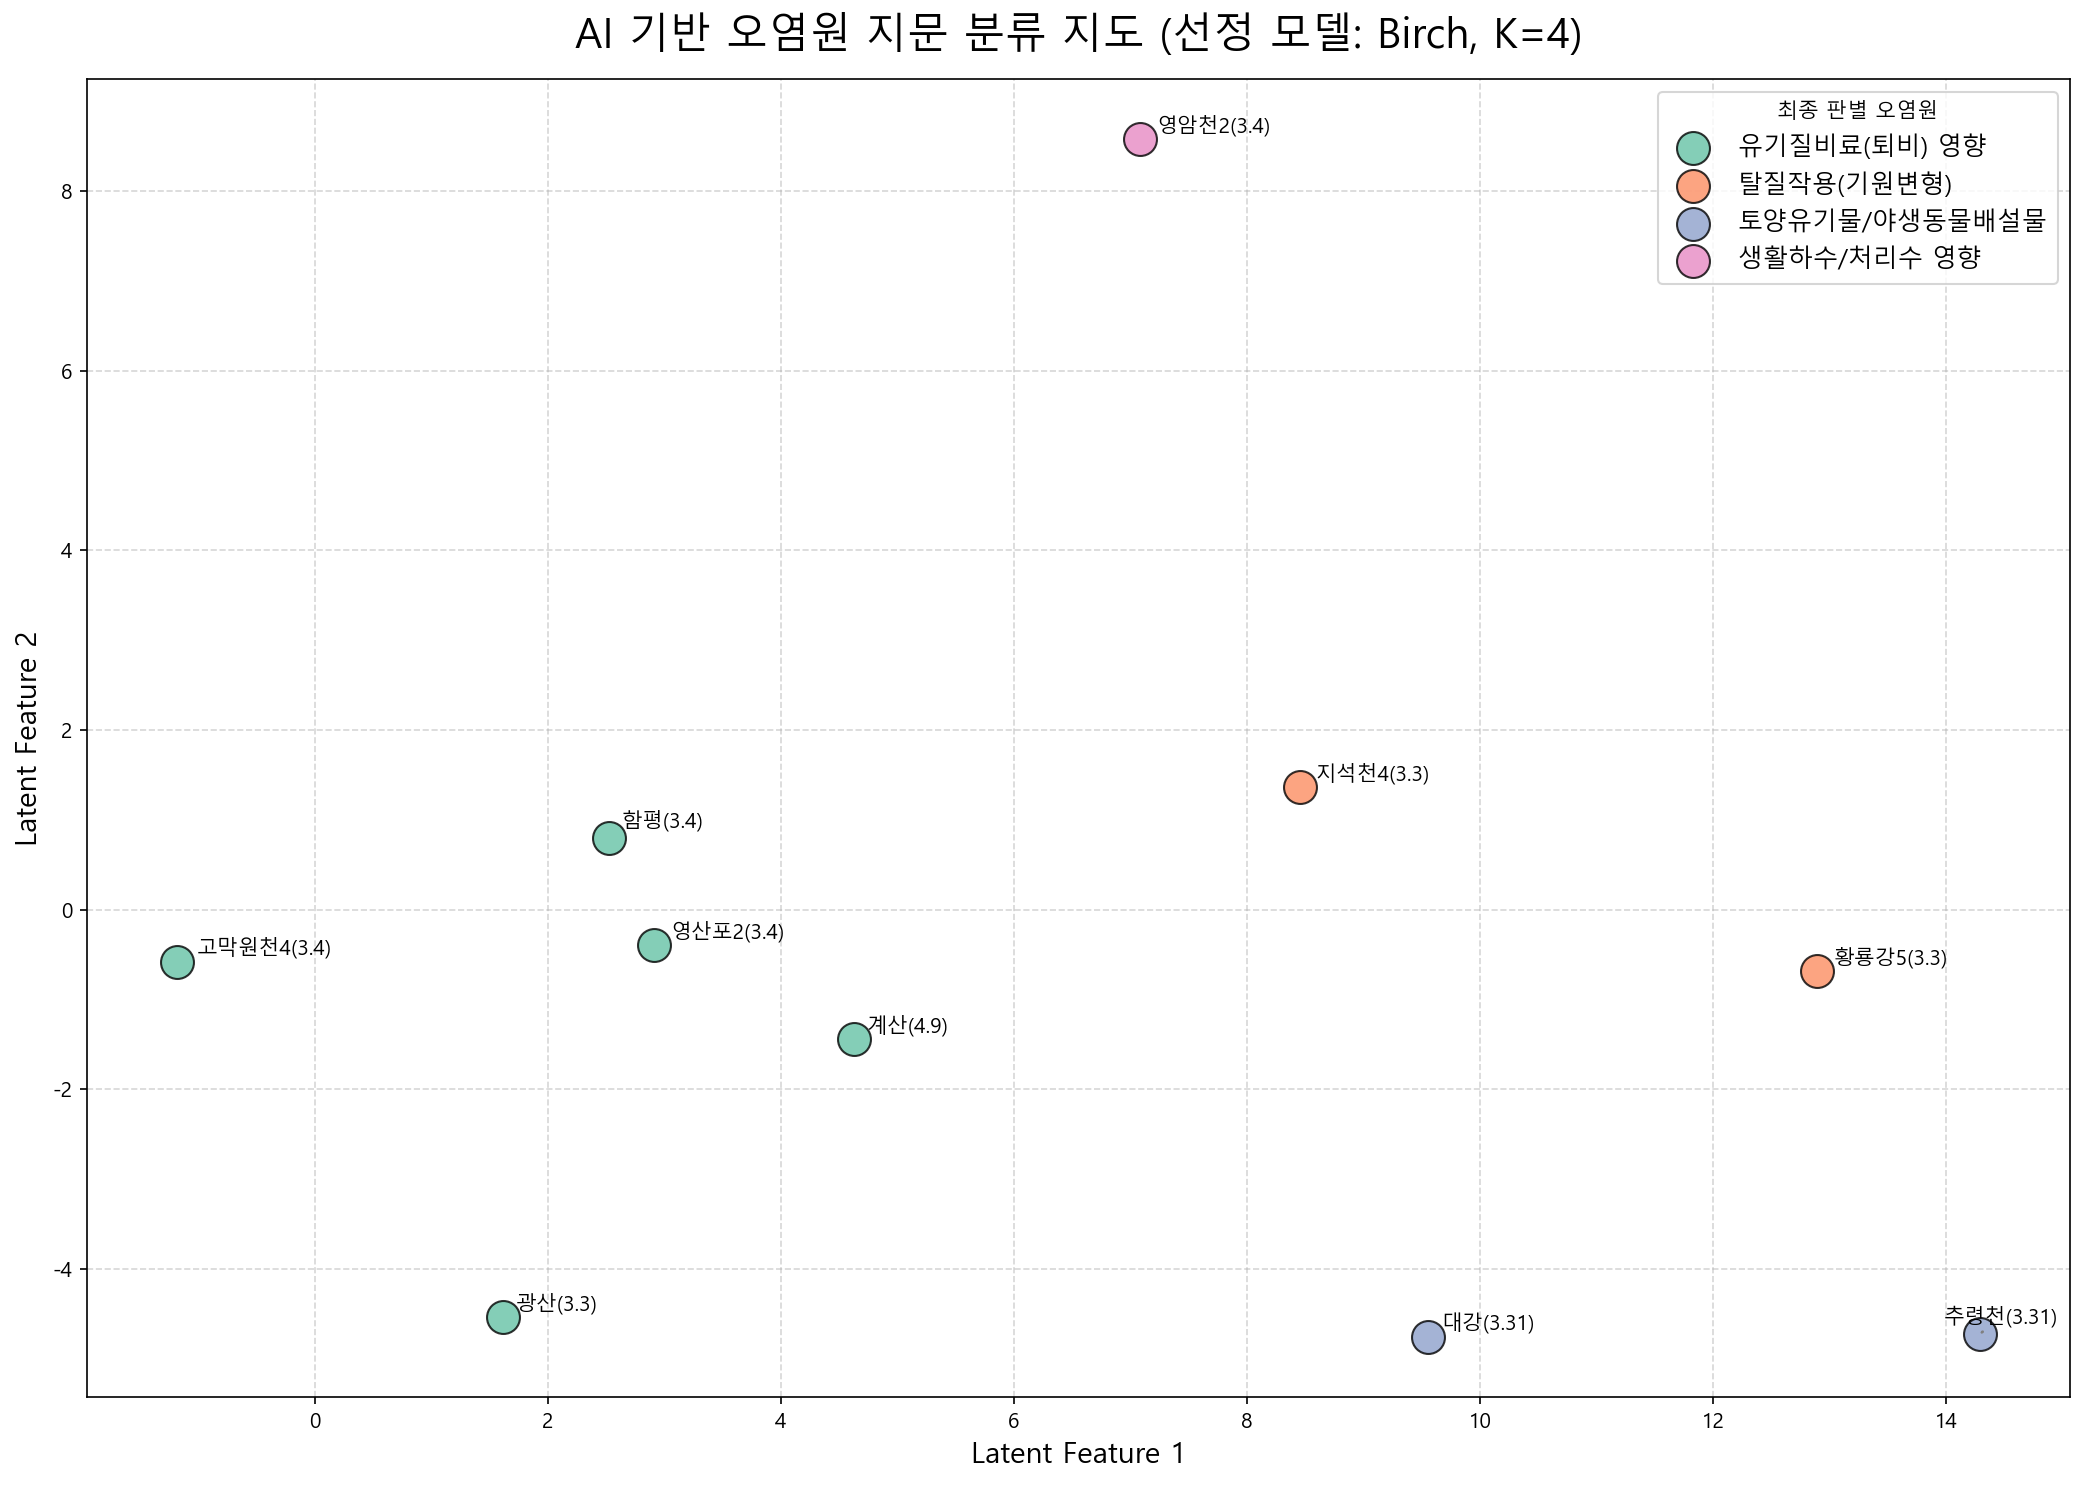

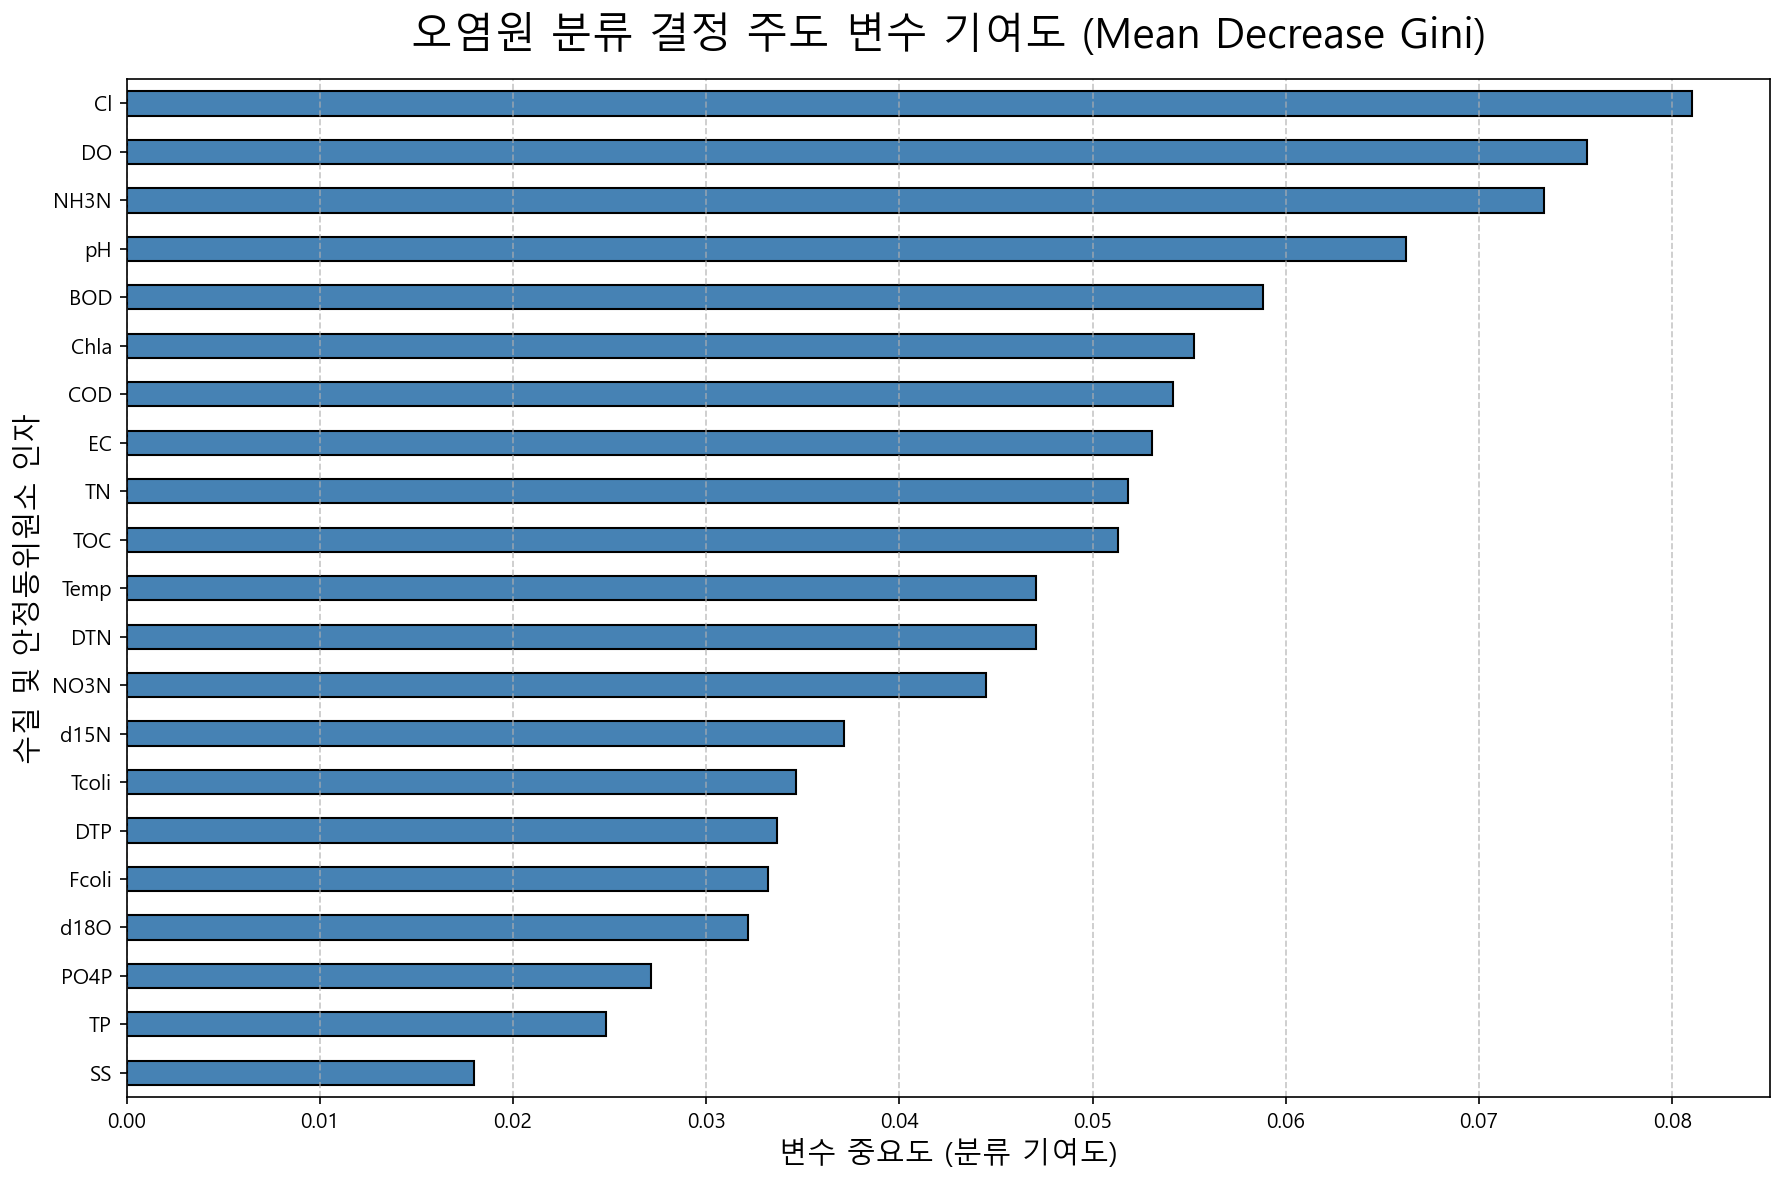

In [17]:
# ------------------------------------------------------------------------------
# 5. 시각화 개별 출력 및 PNG 저장 로직 
# ------------------------------------------------------------------------------
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")

# [방법론] Explainable AI (XAI) - Decision Tree & Random Forest
# [참고문헌] Breiman, L. (2001). Random Forests. Machine Learning.
# [설명] AI의 블랙박스 문제를 해결하기 위해, Decision Tree를 활용한 분류 로직 트리와 Random Forest의 Gini Impurity 기반 변수 중요도를 도출하여 관리자가 오염 분류의 근거를 정량적으로 파악할 수 있게 합니다.

# (1) 의사결정 트리 (Breiman et al., 1984) - 화이트박스 사후 검증용
dt_model = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=42)
dt_model.fit(imputed_data, df['Source_Name']) 

class_names_list = [str(c) for c in dt_model.classes_]

plt.figure(figsize=(30, 15))
plot_tree(dt_model, 
          feature_names=features_df.columns, 
          class_names=class_names_list,
          filled=True, 
          rounded=True, 
          fontsize=18,
          precision=2)
plt.title("AI 기반 수질 군집 분류 로직 트리 (군집별 분류 근거)", fontsize=22, pad=20)
plt.tight_layout()
plt.savefig(f"Decision_Tree_Logic_{current_time}.png", dpi=400, bbox_inches='tight')
plt.show() 

# (2) 잠재 공간 지문 지도 (Latent Space Map)
plt.figure(figsize=(14, 10))
colors = sns.color_palette('Set2', len(mapping))
for i, cluster_id in enumerate(mapping.keys()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(latent_data[mask, 0], latent_data[mask, 1], label=mapping[cluster_id], s=250, color=colors[i], edgecolors='k', alpha=0.8)

texts = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=10) for i in range(len(df))]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
plt.title(f"AI 기반 오염원 지문 분류 지도 (선정 모델: {best_run['model']}, K={best_k})", fontsize=20, pad=15)
plt.xlabel("Latent Feature 1", fontsize=14); plt.ylabel("Latent Feature 2", fontsize=14)
plt.legend(title="최종 판별 오염원", loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"Latent_Space_Map_{current_time}.png", dpi=400, bbox_inches='tight')
plt.show() 

# (3) 변수 중요도 분석 (Mean Decrease Gini - Breiman, 2001)
rf = RandomForestClassifier(n_estimators=500, random_state=42).fit(imputed_data, df['Cluster'])
importances = pd.Series(rf.feature_importances_, index=features_df.columns).sort_values()

plt.figure(figsize=(12, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("오염원 분류 결정 주도 변수 기여도 (Mean Decrease Gini)", fontsize=20, pad=15)
plt.xlabel("변수 중요도 (분류 기여도)", fontsize=14)
plt.ylabel("수질 및 안정동위원소 인자", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"Feature_Importance_{current_time}.png", dpi=400, bbox_inches='tight')
plt.show()

In [18]:
# ------------------------------------------------------------------------------
# 6. 최종 분석 결과 출력 (DataFrame)
# ------------------------------------------------------------------------------
print("\n=========================================================")
print(" [오염원 자동 스크리닝 최종 리포트]")
print("=========================================================")
final_report = df[['spot', 'Source_Name', 'd15N', 'd18O', 'TN', 'NH3N', 'NO3N', 'TP', 'TOC', 'EC', 'Chla', 'Cl']].sort_values('Source_Name')
print(final_report)

final_report.to_csv(f"Screening_Result_{current_time}.csv", index=False, encoding='euc-kr')


 [오염원 자동 스크리닝 최종 리포트]
         spot    Source_Name  d15N  d18O     TN   NH3N   NO3N     TP   TOC  \
6   영암천2(3.4)    생활하수/처리수 영향  12.0   3.7  4.897  0.608  3.301  0.227   8.0   
0     광산(3.3)   유기질비료(퇴비) 영향   1.1  -1.3  9.069  7.048  1.160  0.403  11.9   
1   영산포2(3.4)   유기질비료(퇴비) 영향   9.3   3.1  9.263  6.106  2.651  0.118   8.4   
2     함평(3.4)   유기질비료(퇴비) 영향   8.6   2.7  8.412  5.094  2.979  0.136   8.0   
3  고막원천4(3.4)   유기질비료(퇴비) 영향   5.0   0.9  5.931  0.777  3.569  0.400  11.7   
9     계산(4.9)   유기질비료(퇴비) 영향   5.2   3.4    NaN    NaN  2.486    NaN   NaN   
4   황룡강5(3.3)     탈질작용(기원변형)   6.5   4.1  1.976  0.218  1.137  0.086   8.3   
5   지석천4(3.3)     탈질작용(기원변형)   9.1   2.5  3.346  0.098  2.390  0.186   9.2   
7    대강(3.31)  토양유기물/야생동물배설물   6.1   2.2  1.889    NaN    NaN  0.137   7.6   
8   추령천(3.31)  토양유기물/야생동물배설물   8.1   3.3  3.309    NaN    NaN  0.050   3.6   

       EC  Chla     Cl  
6  1484.0  58.7  387.2  
0   412.0  40.0   66.0  
1   425.0  21.2   59.1  
2   431.0  23.1   